In [5]:
import pandas as pd 
import numpy as np

df = pd.read_csv("../Data/ecommerce_sales_data.csv")
df.head()


,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [6]:
df.shape

(3500, 7)

In [7]:
df.columns

Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   str    
 1   Product Name  3500 non-null   str    
 2   Category      3500 non-null   str    
 3   Region        3500 non-null   str    
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), str(4)
memory usage: 191.5 KB


In [9]:
df.isnull().sum()

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

In [10]:
df.describe()

,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['Order Date'].head(10)

0    2024-12-31
1    2022-11-27
2    2022-05-11
3    2024-03-16
4    2022-09-10
5    2023-12-01
6    2023-10-09
7    2022-01-14
8    2022-04-02
9    2024-10-22
Name: Order Date, dtype: str

In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors = 'coerce')

In [14]:
df['Order Date'].head()

0   2024-12-31
1   2022-11-27
2   2022-05-11
3   2024-03-16
4   2022-09-10
Name: Order Date, dtype: datetime64[us]

In [15]:
df['Order Date'].isna().sum()

np.int64(0)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    3500 non-null   datetime64[us]
 1   Product Name  3500 non-null   str           
 2   Category      3500 non-null   str           
 3   Region        3500 non-null   str           
 4   Quantity      3500 non-null   int64         
 5   Sales         3500 non-null   int64         
 6   Profit        3500 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 191.5 KB


In [17]:
df['Quantity'] =df['Quantity'].astype('int32')
df['Sales'] =df['Sales'].astype('int32')
df['Profit'] =df['Profit'].astype('float32')
df['Product Name'] =df['Product Name'].astype('category')
df['Category'] =df['Category'].astype('category')
df['Region'] =df['Region'].astype('category')
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    3500 non-null   datetime64[us]
 1   Product Name  3500 non-null   category      
 2   Category      3500 non-null   category      
 3   Region        3500 non-null   category      
 4   Quantity      3500 non-null   int32         
 5   Sales         3500 non-null   int32         
 6   Profit        3500 non-null   float32       
dtypes: category(3), datetime64[us](1), float32(1), int32(2)
memory usage: 78.9 KB


In [18]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.929993
1,2022-11-27,Mouse,Accessories,East,7,1197,106.529999
2,2022-05-11,Tablet,Electronics,South,5,5865,502.730011
3,2024-03-16,Mouse,Accessories,South,2,786,202.869995
4,2022-09-10,Mouse,Accessories,West,1,509,103.279999


In [19]:
#total Profit
total_profit = df['Profit'].sum()
print("The total profit is:" , total_profit)

The total profit is: 1.8446652e+06


In [20]:
#Total Sales
total_Sales = df['Sales'].sum()
print("The total Sales is:" , total_Sales)

# Total Quantity
total_Quantity = df['Quantity'].sum()
print("The total Quantity is:" , total_Quantity)

##Average Sales and Profit
print("The average profit:" , df['Profit'].mean())
print("The average Sales:" , df['Sales'].mean())

The total Sales is: 10667881
The total Quantity is: 17261
The average profit: 527.04724
The average Sales: 3047.966


In [21]:
#Best-performing Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending = False)
category_sales

Category
Electronics    5326074
Accessories    4247591
Office         1094216
Name: Sales, dtype: int32

In [22]:
# Category Profit
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending = False)
category_profit

Category
Electronics    923185.5625
Accessories    736084.7500
Office         185394.8750
Name: Profit, dtype: float32

In [23]:
##Best Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending = False)
region_sales

Region
West     2844450
East     2675110
South    2659548
North    2488773
Name: Sales, dtype: int32

In [24]:
## Best Region Profit
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending = False)
region_profit

Region
West     495358.71875
East     464888.46875
South    458103.28125
North    426314.75000
Name: Profit, dtype: float32

In [25]:
#Top 10 product by Sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending = False).head(10)
top_products

Product Name
Camera        1177381
Monitor       1160048
Printer       1094216
Mouse         1074398
Smartphone    1069681
Smartwatch    1049211
Keyboard      1024507
Tablet        1023928
Laptop        1005873
Headphones     988638
Name: Sales, dtype: int32

In [26]:
##Top 10 product by profit
top_products_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending = False).head(10)
top_products_profit

Product Name
Camera        207630.984375
Monitor       202028.171875
Mouse         185763.687500
Laptop        185756.812500
Printer       185394.875000
Smartphone    183296.968750
Smartwatch    178995.812500
Keyboard      175814.687500
Headphones    172478.203125
Tablet        167505.015625
Name: Profit, dtype: float32

In [27]:
# Convert Order Date to Date time
df['Order Date'] = pd.to_datetime(df['Order Date'], errors = 'coerce')
# Create Month Column
df['Monthly'] = df['Order Date'].dt.to_period('M')
# Monthly Sales
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
print("Monthly Sales:", monthly_sales)
# Monthly Profit
monthly_profit = df.groupby(df['Order Date'].dt.to_period('M'))['Profit'].sum()
monthly_profit

Monthly Sales: Order Date
2022-01    341544
2022-02    208775
2022-03    294660
2022-04    230624
2022-05    314295
2022-06    273851
2022-07    214627
2022-08    296242
2022-09    240211
2022-10    324989
2022-11    257111
2022-12    259041
2023-01    343256
2023-02    313931
2023-03    303391
2023-04    280808
2023-05    346481
2023-06    251686
2023-07    320798
2023-08    388428
2023-09    303409
2023-10    253145
2023-11    306195
2023-12    375064
2024-01    282814
2024-02    179708
2024-03    341563
2024-04    310444
2024-05    373911
2024-06    314268
2024-07    309515
2024-08    240269
2024-09    341926
2024-10    314135
2024-11    291769
2024-12    324997
Freq: M, Name: Sales, dtype: int32


Order Date
2022-01    63827.328125
2022-02    34084.898438
2022-03    51931.808594
2022-04    44260.449219
2022-05    53504.968750
2022-06    48490.929688
2022-07    40010.269531
2022-08    47551.992188
2022-09    41402.820312
2022-10    52927.238281
2022-11    50120.691406
2022-12    44743.582031
2023-01    63708.781250
2023-02    53645.429688
2023-03    53442.667969
2023-04    49178.671875
2023-05    59087.730469
2023-06    43445.750000
2023-07    55207.398438
2023-08    65590.617188
2023-09    51010.492188
2023-10    44505.750000
2023-11    52537.371094
2023-12    75505.757812
2024-01    49744.179688
2024-02    31228.390625
2024-03    56762.148438
2024-04    52181.839844
2024-05    60700.449219
2024-06    51261.851562
2024-07    54026.441406
2024-08    39817.281250
2024-09    57851.730469
2024-10    55594.980469
2024-11    42179.730469
2024-12    53592.789062
Freq: M, Name: Profit, dtype: float32

In [28]:
#Highest Sales Month
highest_month = monthly_sales.idxmax()
highest_sales = monthly_sales.max()
print("Highest Sales Month:", highest_month)
print("Sales:", highest_sales)

Highest Sales Month: 2023-08
Sales: 388428


In [29]:
#Lowest Sales Month
lowest_month = monthly_sales.idxmin()
lowest_sales = monthly_sales.min()
print("Lowest Sales Month:", lowest_month)
print("Sales:", lowest_sales)

Lowest Sales Month: 2024-02
Sales: 179708


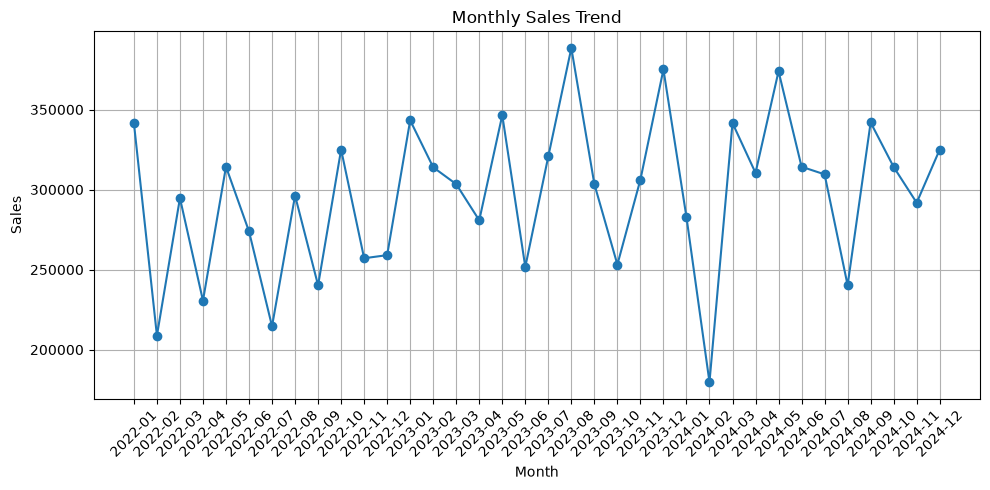

In [30]:
# Monthly Sales Graph
import matplotlib.pyplot as plt

x = monthly_sales.index.astype(str)
y = monthly_sales.values

plt.figure(figsize = (10, 5))
plt.plot(x, y, marker = 'o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation = 45)
plt.grid()
plt.tight_layout()
plt.savefig("../outputs/monthly_sales.png")
plt.show()

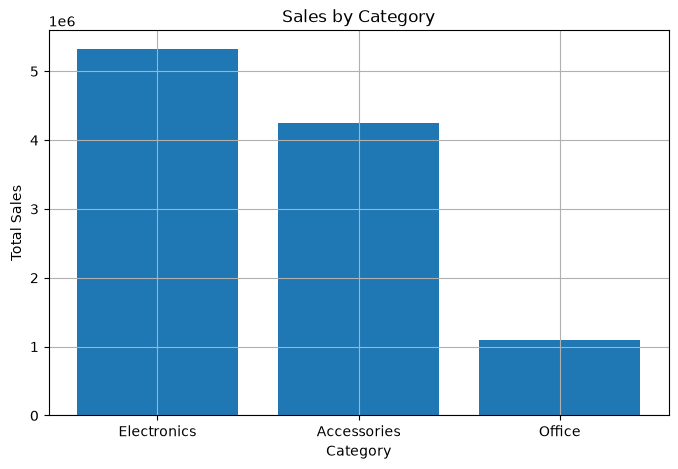

In [31]:
# Sales by Category Bar Graph
import matplotlib.pyplot as plt

x = category_sales.index
y = category_sales.values

plt.figure(figsize=(8,5))
plt.bar(x, y,)
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.title('Sales by Category')
plt.grid()
plt.savefig("../outputs/category_sales.png")
plt.show()

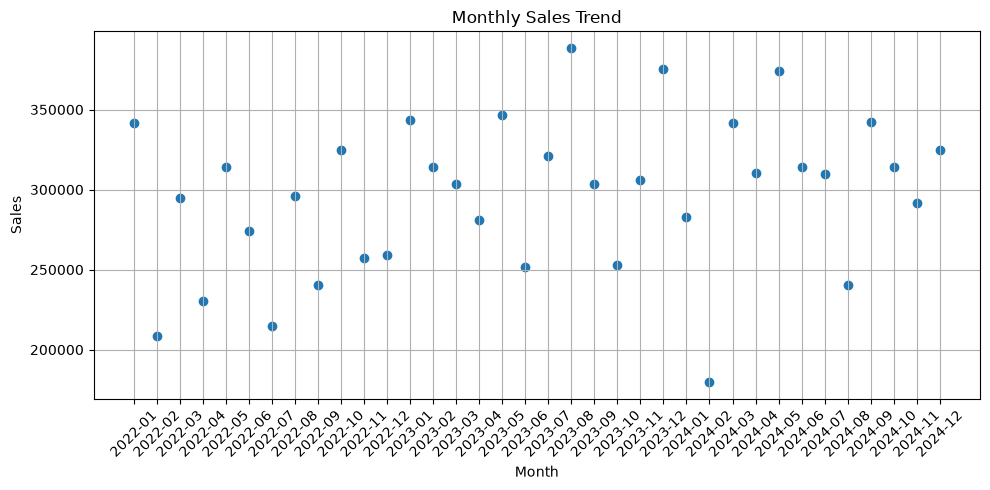

In [32]:
#Monthly Sales Sactter Graph 

import matplotlib.pyplot as plt

x = monthly_sales.index.astype(str)
y = monthly_sales.values

plt.figure(figsize = (10, 5))
plt.scatter(x, y, marker = 'o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation = 45)
plt.grid()
plt.tight_layout()
plt.show()

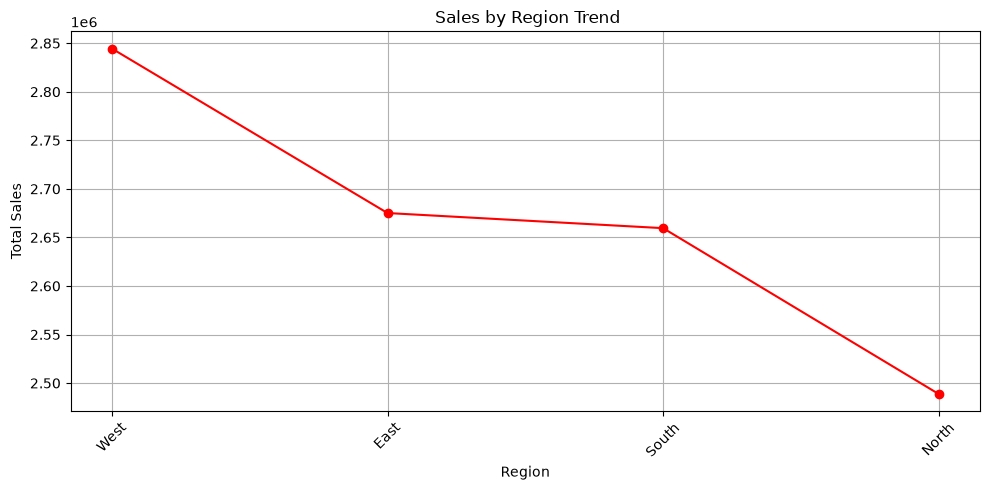

In [33]:
#Graph by Region Sales

import matplotlib.pyplot as plt

x = region_sales.index.astype(str)
y = region_sales.values

plt.figure(figsize = (10, 5))
plt.plot(x, y, marker = 'o', color = 'Red')
plt.title(' Sales by Region Trend')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation = 45)
plt.grid()
plt.tight_layout()
plt.savefig("../outputs/region_sales.png")
plt.show()

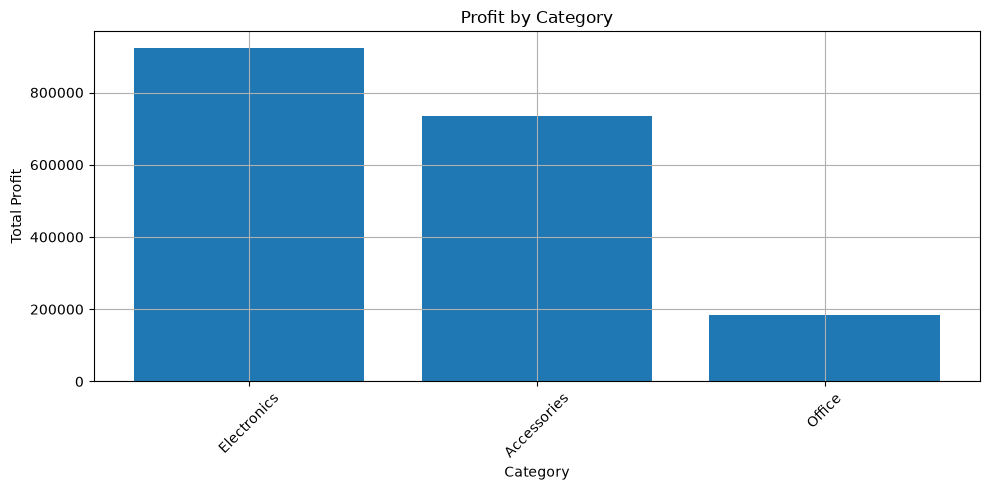

In [34]:
import matplotlib.pyplot as plt

x = category_profit.index.astype('str')
y = category_profit.values

plt.figure(figsize = (10, 5))
plt.bar(x, y,)
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation = 45)
plt.grid()
plt.tight_layout()
plt.savefig("../outputs/category_profit.png")
plt.show()

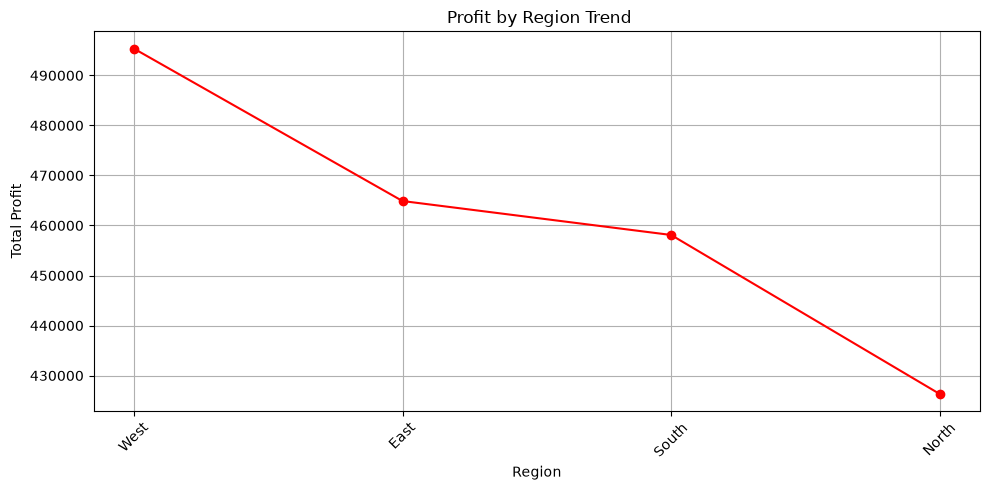

In [35]:
#Graph by Region Profit

import matplotlib.pyplot as plt

x = region_profit.index.astype(str)
y = region_profit.values

plt.figure(figsize = (10, 5))
plt.plot(x, y, marker = 'o', color = 'Red')
plt.title(' Profit by Region Trend')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.xticks(rotation = 45)
plt.grid()
plt.tight_layout()
plt.savefig("../outputs/region_profit.png")
plt.show()

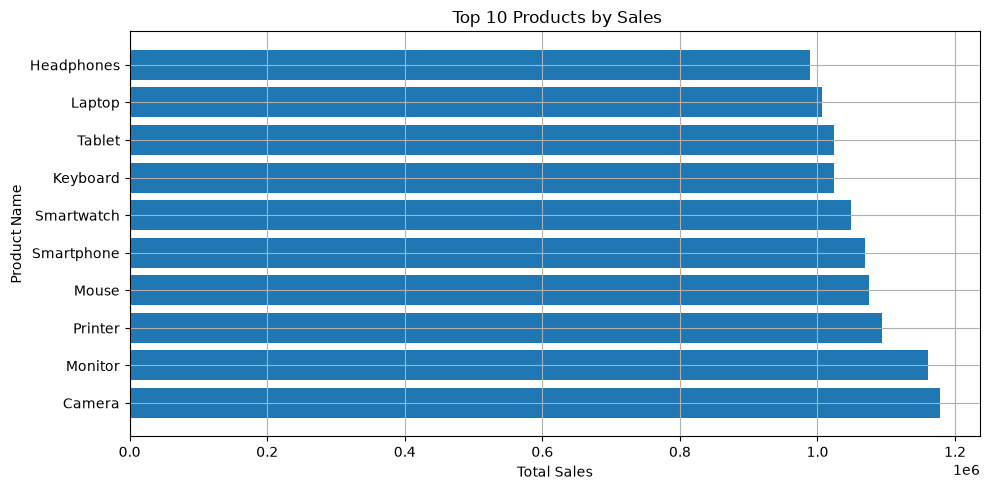

In [37]:
#Top 10 Products by Sales

import matplotlib.pyplot as plt

x = top_products.index.astype(str)
y = top_products.values

plt.figure(figsize = (10, 5))
plt.barh(x, y,)
plt.title(' Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.grid()
plt.tight_layout()
plt.savefig("../outputs/top_products.png")
plt.show()


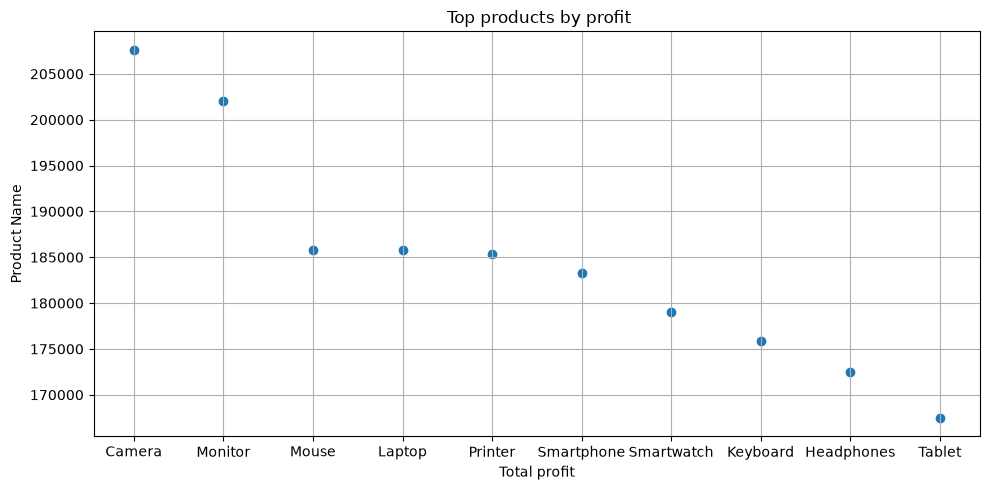

In [38]:
# Top 10 products by Profit
import matplotlib.pyplot as plt

x = top_products_profit.index.astype(str)
y = top_products_profit.values

plt.figure(figsize = (10, 5))
plt.scatter(x, y,)
plt.title(' Top products by profit')
plt.xlabel('Total profit')
plt.ylabel('Product Name')
plt.grid()
plt.tight_layout()
plt.savefig("../outputs/top_products_profit.png")
plt.show()

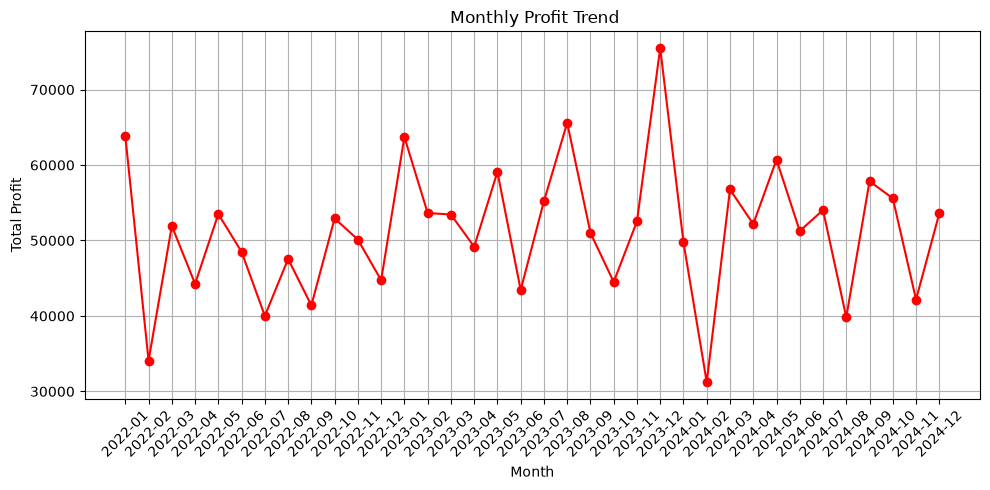

In [39]:
import matplotlib.pyplot as plt

x = monthly_profit.index.astype(str)
y = monthly_profit.values

plt.figure(figsize = (10, 5))
plt.plot(x, y, marker = 'o', color = 'Red')
plt.title(' Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Total Profit')
plt.xticks(rotation = 45)
plt.grid()
plt.tight_layout()
plt.savefig("../outputs/monthly_profit.png")
plt.show()

In [40]:
#Business Insights
print("BUSINESS INSIGHTS")
print("1. Total Sales:", df['Sales'].sum())
print("2. Total Profit:", df['Profit'].sum())
print("3. Total Quantity Sold:", df['Quantity'].sum())
print("4. Best Selling Category:", (category_sales.idxmax(), category_sales.max()))
print("5. Most Profitable Category :", (category_profit.idxmax(), category_profit.max()))
print("6. Best Region by Sales:", (region_sales.idxmax(), region_sales.max()))
print("7. Best Selling Product:", (top_products.idxmax(), top_products.max()))
print("8. Highest Sale Month:", (monthly_sales.idxmax(),monthly_sales.max()))
print("9. Lowest Sale Month:", (monthly_sales.idxmin(),monthly_sales.min()))

BUSINESS INSIGHTS
1. Total Sales: 10667881
2. Total Profit: 1.8446652e+06
3. Total Quantity Sold: 17261
4. Best Selling Category: ('Electronics', np.int32(5326074))
5. Most Profitable Category : ('Electronics', np.float32(923185.56))
6. Best Region by Sales: ('West', np.int32(2844450))
7. Best Selling Product: ('Camera', np.int32(1177381))
8. Highest Sale Month: (Period('2023-08', 'M'), np.int32(388428))
9. Lowest Sale Month: (Period('2024-02', 'M'), np.int32(179708))


In [41]:
#Profit Margin

profit_margin = (df['Profit'].sum()/df['Sales'].sum())*100
print("Overall Profit Margin:",round(profit_margin, 2), "%")

Overall Profit Margin: 17.29 %


In [42]:
df["profit_margin"] = np.where(df["Sales"]!= 0,(df["Profit"]/df["Sales"])*100,0)
print(df[["Sales", "Profit", "profit_margin"]].head())

   Sales      Profit  profit_margin
0   3640  348.929993       9.585989
1   1197  106.529999       8.899749
2   5865  502.730011       8.571697
3    786  202.869995      25.810432
4    509  103.279999      20.290766


In [43]:
#Most Profitable Region
print("Profit by Region:")
print(region_profit)
print("Most profitable region:",region_profit.idxmax(), region_profit.max())

Profit by Region:
Region
West     495358.71875
East     464888.46875
South    458103.28125
North    426314.75000
Name: Profit, dtype: float32
Most profitable region: West 495358.72


In [44]:
##Loss-Making Products
loss_products = (df.groupby("Product Name")["Profit"].sum().sort_values())
print(loss_products.head())

Product Name
Tablet        167505.015625
Headphones    172478.203125
Keyboard      175814.687500
Smartwatch    178995.812500
Smartphone    183296.968750
Name: Profit, dtype: float32
